# Análise técnica — setor de alimentação fora do lar

**Fonte:** Dados abertos de CNPJ da Receita Federal, competência 2026-08.  
**Recorte:** seis CNAEs de bares, restaurantes e alimentação fora do lar.

## Respostas em 30 segundos

| Pergunta do teste | Resposta |
|---|---|
| Quantas empresas estão ativas hoje? | **1.511.132 empresas** |
| Como foram as aberturas nos últimos 5 anos? | **1.507.905 empresas abertas** de 2021 a 2025 |
| Qual é o porte predominante? | **MEI: 63,1%** das empresas ativas |


## Como os dados foram preparados

- Os scripts `01_ingestao.py` e `02_tratamento.py` convertem os arquivos da Receita, unem Empresas e Estabelecimentos e filtram os seis CNAEs.
- Foram usadas as **10 partes nacionais** dos arquivos; uma parte isolada não cobre os cinco anos de forma confiável.
- Nesta análise, cada empresa é contada pelo **CNPJ básico**; filiais não viram empresas duplicadas.


In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
from IPython.display import display

# Mesma paleta do dashboard, aplicada de modo leve no notebook.
CORES = {
    'terracota': '#E0533C', 'laranja': '#F08C28', 'oliva': '#4E8752',
    'azul': '#3B728C', 'azul_claro': '#9ABECF', 'bege': '#D5C9BF',
    'grade': '#EADFD7',
}
plt.rcParams.update({
    'figure.facecolor': '#F5EFEB', 'axes.facecolor': '#FFFFFF',
    'axes.titleweight': 'bold', 'axes.titlecolor': '#2D231E',
    'axes.labelcolor': '#5C4D44', 'xtick.color': '#5C4D44',
    'ytick.color': '#5C4D44', 'font.size': 11,
})

def tabela(df):
    return (df.style
        .format(precision=1, thousands='.', decimal=',')
        .set_properties(**{'background-color': '#FAF6F0', 'color': '#2D231E', 'padding': '8px 12px'})
        .set_table_styles([
            {'selector': 'th', 'props': [('background-color', '#E0533C'), ('color', 'white'), ('padding', '8px 12px')]},
            {'selector': 'table', 'props': [('border-collapse', 'separate'), ('border-spacing', '0 4px')]},
        ]))

def finalizar(ax, eixo):
    ax.grid(axis=eixo, color=CORES['grade'], linewidth=1.1)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color(CORES['grade'])
    ax.spines['bottom'].set_color(CORES['grade'])

RAIZ = Path.cwd() if (Path.cwd() / 'dados').exists() else Path.cwd().parent
con = duckdb.connect()
con.execute(f"CREATE VIEW base AS SELECT * FROM read_parquet('{RAIZ}/dados/tratados/base_afl.parquet')")


## 1. Quantas empresas do setor estão ativas hoje?

**Resposta:** existem **1.511.132 empresas ativas**, distribuídas em 1.543.267 estabelecimentos. A diferença acontece porque uma empresa pode ter matriz e filiais.


In [2]:
ativas = con.sql('''
    SELECT
        count(DISTINCT cnpj_basico) AS empresas_ativas,
        count(*) AS estabelecimentos_ativos
    FROM base
    WHERE situacao = 'Ativa'
''').df()

display(tabela(ativas))


,empresas_ativas,estabelecimentos_ativos
0,1.511.132,1.543.267


## 2. Como evoluiu a abertura de empresas nos últimos 5 anos?

**Resposta:** de 2021 a 2025, foram abertas **1.507.905 empresas**. O maior volume ocorreu em 2021; depois do menor ponto em 2023, o ritmo voltou a crescer em 2024 e 2025.


,ano,novas_aberturas
0,2.021,356.849
1,2.022,282.586
2,2.023,268.190
3,2.024,284.904
4,2.025,315.376


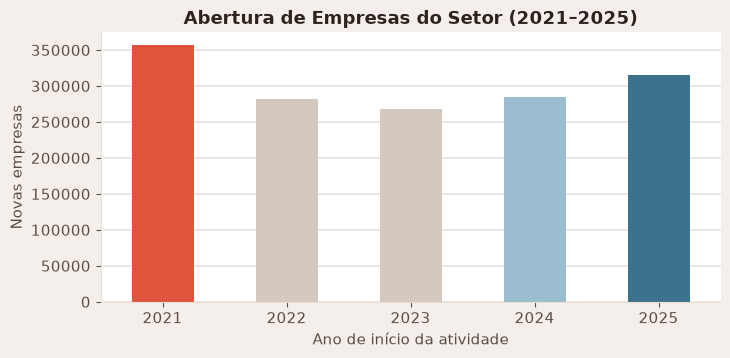

In [3]:
aberturas = con.sql('''
    SELECT ano_inicio AS ano, count(*) AS novas_aberturas
    FROM base
    WHERE ano_inicio BETWEEN 2021 AND 2025
    GROUP BY 1
    ORDER BY 1
''').df()

display(tabela(aberturas))

ax = aberturas.plot.bar(
    x='ano', y='novas_aberturas', legend=False, rot=0, figsize=(8, 3.5),
    color=[CORES['terracota'], CORES['bege'], CORES['bege'], CORES['azul_claro'], CORES['azul']]
)
ax.set_title('Abertura de Empresas do Setor (2021–2025)')
ax.set_xlabel('Ano de início da atividade')
ax.set_ylabel('Novas empresas')
finalizar(ax, 'y')


## 3. Qual é o porte predominante?

**Resposta:** **MEI** é o porte predominante: representa **63,1%** das empresas ativas. O campo de porte da Receita não identifica MEI sozinho; por isso, a classificação foi complementada com a base do Simples Nacional.


,porte,empresas,percentual
3,MEI,953.769,"63,1"
2,Microempresa,486.715,"32,2"
1,Empresa de pequeno porte,59.403,"3,9"
0,Demais,11.245,"0,7"


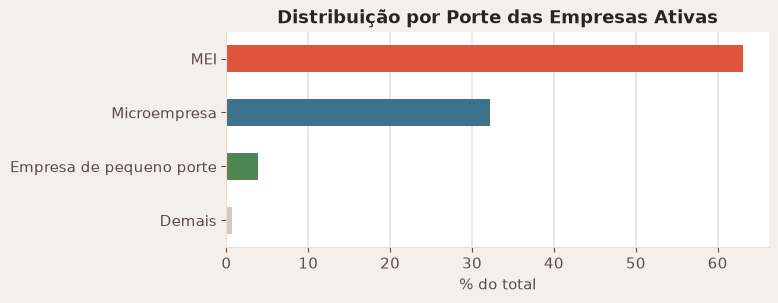

In [4]:
porte = con.sql('''
    SELECT
        CASE WHEN mei = 'MEI' THEN 'MEI' ELSE porte END AS porte,
        count(DISTINCT cnpj_basico) AS empresas
    FROM base
    WHERE situacao = 'Ativa'
    GROUP BY 1
    ORDER BY empresas ASC
''').df()
porte['percentual'] = (porte['empresas'] / porte['empresas'].sum() * 100).round(1)

display(tabela(porte.sort_values('empresas', ascending=False)))

ax = porte.plot.barh(
    x='porte', y='percentual', legend=False, figsize=(7, 2.8),
    color=[CORES['bege'], CORES['oliva'], CORES['azul'], CORES['terracota']]
)
ax.set_title('Distribuição por Porte das Empresas Ativas')
ax.set_xlabel('% do total')
ax.set_ylabel('')
finalizar(ax, 'x')


## Nota de qualidade dos dados

- A análise nacional usa 72.789.638 estabelecimentos da Receita Federal.
- Empresas e estabelecimentos foram unidos pelo CNPJ básico, sem registros AFL sem empresa correspondente.
- A base tratada completa está na release do repositório em Parquet; a pasta `dados/amostra` contém uma amostra CSV para consulta rápida.


## Conclusão

O setor é formado principalmente por pequenos negócios: 1,5 milhão de empresas ativas, com forte presença de MEI. No período de 2021 a 2025, houve mais de 1,5 milhão de aberturas, com retomada no fim da série.
